In [92]:
import xgboost as xgb
import numpy as np
from xgboost import plot_tree
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

In [93]:
import pickle
with open("Dictionaries/origin_rate_dict.pkl", "rb") as f:
    origin_rate_dict = pickle.load(f)
    
with open("Dictionaries/destination_rate_dict.pkl", "rb") as f:
    destination_rate_dict = pickle.load(f)

with open("Dictionaries/vendors_dict.pkl", "rb") as f:
    vendors_dict = pickle.load(f)
    
with open("Dictionaries/unique_vendors.pkl", "rb") as f:
    unique_vendors = pickle.load(f)

with open("Dictionaries/origin_rate_dict.pkl", "rb") as f:
    origin_rate_dict = pickle.load(f)

with open("Dictionaries/journey_mileage_dict.pkl", "rb") as f:
    journey_mileage_dict = pickle.load(f)

with open("Dictionaries/journey_duration_dict.pkl", "rb") as f:
    journey_duration_dict = pickle.load(f)

In [94]:
def peak_pred(first_departure_minute):
    peak_bool = (first_departure_minute >= 7*60) & (first_departure_minute < 9*60) | (first_departure_minute >= 21*60) & (first_departure_minute < 23*60)
    return peak_bool

def pred_AB(route_string, week_day, search_horizon_hours, first_departure_minute):
    duration = journey_duration_dict[route_string]
    mileage = journey_mileage_dict[route_string]
    vendor = vendors_dict[route_string]
    num_stops = route_string.split(',').__len__()
    speed = mileage / duration
    peak_bool = peak_pred(first_departure_minute)
    origin_congest = origin_rate_dict[(peak_bool, route_string.split(',')[0])]
    destination_congest = destination_rate_dict[(peak_bool, route_string.split(',')[-1])]
    num_vendors = 1
    num_pipes = 0
    uv_d = {uv:0 for uv in unique_vendors}
    for v in vendor:
        uv_d[v] = 1
    route_dict = {
        'journey_duration': duration, 
        'journey_mileage': mileage, 
        'num_intermediate_points': num_stops, 
        'speed': speed, 
        'peak_hour': peak_bool, 
        'num_vendors': num_vendors, 
        'vendor': vendor, 
        'num_pipes': num_pipes,
        'weekday': week_day,
        'search_horizon_hours': search_horizon_hours,
        'sh_days': (search_horizon_hours//24),
        "departure_minute": first_departure_minute,
        "holiday": 0,
        'origin_rate': origin_congest,
        'destination_rate': destination_congest,
    }
    route_dict.update(uv_d)
    return route_dict

In [142]:
# Load and xgboost model from file

nn = False
if nn:
    loaded_model = tf.saved_model.load('neural_network')
else:
    loaded_model = xgb.Booster()
    loaded_model.load_model('xgb_model.ubj')

In [143]:
inter = ['KGX', 'PBO', 'NNG', 'DON', 'YRK', 'NTR', 'DAR', 'DHM', 'NCL', 'EDB']

all_posible_routes = []
for i in range(len(inter)):
    for j in range(i+1, len(inter)):
        all_posible_routes.append(",".join(inter[i:j+1]))
all_posible_routes

['KGX,PBO',
 'KGX,PBO,NNG',
 'KGX,PBO,NNG,DON',
 'KGX,PBO,NNG,DON,YRK',
 'KGX,PBO,NNG,DON,YRK,NTR',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR,DHM',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'PBO,NNG',
 'PBO,NNG,DON',
 'PBO,NNG,DON,YRK',
 'PBO,NNG,DON,YRK,NTR',
 'PBO,NNG,DON,YRK,NTR,DAR',
 'PBO,NNG,DON,YRK,NTR,DAR,DHM',
 'PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL',
 'PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'NNG,DON',
 'NNG,DON,YRK',
 'NNG,DON,YRK,NTR',
 'NNG,DON,YRK,NTR,DAR',
 'NNG,DON,YRK,NTR,DAR,DHM',
 'NNG,DON,YRK,NTR,DAR,DHM,NCL',
 'NNG,DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'DON,YRK',
 'DON,YRK,NTR',
 'DON,YRK,NTR,DAR',
 'DON,YRK,NTR,DAR,DHM',
 'DON,YRK,NTR,DAR,DHM,NCL',
 'DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'YRK,NTR',
 'YRK,NTR,DAR',
 'YRK,NTR,DAR,DHM',
 'YRK,NTR,DAR,DHM,NCL',
 'YRK,NTR,DAR,DHM,NCL,EDB',
 'NTR,DAR',
 'NTR,DAR,DHM',
 'NTR,DAR,DHM,NCL',
 'NTR,DAR,DHM,NCL,EDB',
 'DAR,DHM',
 'DAR,DHM,NCL',
 'DAR,DHM,NCL,EDB',
 'DHM,NCL',
 'DHM,NC

In [144]:
weekday = 1
search_horizon_hours = 31 * 24

In [145]:
test = pd.DataFrame.from_dict(pred_AB(all_posible_routes[0], weekday, search_horizon_hours, 12*60))

In [146]:
if nn:
    features = [
        'journey_duration',
        'sh_days',
        'search_horizon_hours',
       'journey_mileage',
       'weekday',
       'holiday',
       'peak_hour',
       'num_intermediate_points',
       'num_vendors',
       'origin_rate',
       'destination_rate',
       'num_pipes']
else:
    features = [
    'weekday', 
    'departure_minute', 
    'search_horizon_hours', 
    'journey_mileage', 
    'journey_duration', 
    'speed', 
    'peak_hour',
    'num_intermediate_points',
    'num_vendors',
    'num_pipes' # Prob remove
    ]
    features.extend(unique_vendors)
target = 'cheapest_standard_class'

In [147]:
if nn:
    print(loaded_model.serve(test[features].values))
else:
    print(loaded_model.predict(xgb.DMatrix(data=test[features], enable_categorical=True)))

[23.818686]


In [148]:
import networkx as nx
from tqdm import tqdm

graph = nx.DiGraph()

weekday = 1
search_horizon_hours = 31 * 24

for route in tqdm(all_posible_routes):
    tmp = route.split(",")
    start = inter.index(tmp[0])
    end = inter.index(tmp[-1])
    
    inputs = pd.DataFrame.from_dict(pred_AB(route, weekday, search_horizon_hours, 12*60))
    if nn:
        cost = loaded_model.serve(inputs[features].values).numpy().squeeze()
    else:
        cost = loaded_model.predict(xgb.DMatrix(data=inputs[features], enable_categorical=True)).tolist()[0]
    
    graph.add_edge(start, end, weight=round(float(cost), 2))

100%|██████████| 45/45 [00:00<00:00, 124.54it/s]


{(0, 1): Text(0.5000002477318048, 0.0, "{'weight': 23.82}"),
 (0, 2): Text(0.9999732701107855, 0.0, "{'weight': 31.32}"),
 (0, 3): Text(1.5000097987940535, 0.0, "{'weight': 34.74}"),
 (0, 4): Text(1.9999559004791072, 0.0, "{'weight': 30.71}"),
 (0, 5): Text(2.500030233495637, 0.0, "{'weight': 52.34}"),
 (0, 6): Text(3.00002374505857, 0.0, "{'weight': 77.34}"),
 (0, 7): Text(3.5000085811770987, 0.0, "{'weight': 77.15}"),
 (0, 8): Text(3.9999631012324235, 0.0, "{'weight': 100.06}"),
 (0, 9): Text(4.500010569841832, 0.0, "{'weight': 95.72}"),
 (1, 2): Text(1.500000247731804, 0.0, "{'weight': 17.26}"),
 (1, 3): Text(1.999973270110786, 0.0, "{'weight': 21.35}"),
 (1, 4): Text(2.5000097987940535, 0.0, "{'weight': 32.5}"),
 (1, 5): Text(2.999955900479107, 0.0, "{'weight': 27.58}"),
 (1, 6): Text(3.500030233495636, 0.0, "{'weight': 31.17}"),
 (1, 7): Text(4.00002374505857, 0.0, "{'weight': 37.87}"),
 (1, 8): Text(4.500008581177097, 0.0, "{'weight': 43.82}"),
 (1, 9): Text(4.999963101232423, 0.

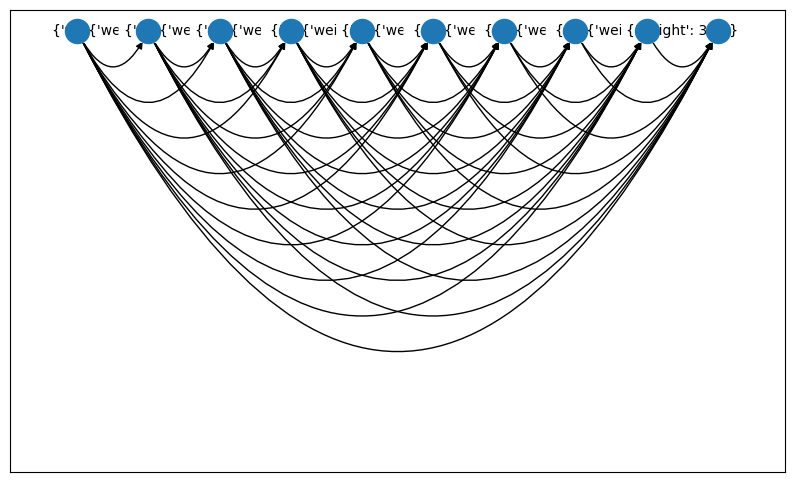

In [149]:
pos = {u: (u, 0) for u in graph.nodes()}

fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_nodes(graph, pos, ax=ax)
nx.draw_networkx_edges(
    graph, pos,
    connectionstyle="arc3,rad=1",
    arrows=True,
    ax=ax
)
edge_labels = nx.get_edge_attributes(graph, 'weight')

# Draw edge labels
nx.draw_networkx_edge_labels(graph, pos)

In [198]:
aug_graph = nx.DiGraph()

k = 4
N = len(inter)

for u, v in graph.edges():
    for i in range(k):
        if (i == 0 and u !=0) or (i == k-1 and v != N-1) or (i > u):
            continue
        aug_graph.add_edge((i, u), (i + 1, v), w=graph[u][v]['weight'])

for i in range(1, k):
    aug_graph.add_edge((i, N-1), (i+1, N-1), w=0)

{((0, 0), (1, 1)): Text(0.4999820892699064, 9.500017910730092, "{'w': 23.82}"),
 ((0, 0), (1, 2)): Text(0.499983232934028, 9.000033534131942, "{'w': 31.32}"),
 ((0, 0),
  (1, 3)): Text(0.49999546876642864, 8.500013593700713, "{'w': 34.74}"),
 ((0, 0), (1, 4)): Text(0.4999949660850689, 8.000020135659723, "{'w': 30.71}"),
 ((0, 0), (1, 5)): Text(0.5000077799195425, 7.499961100402286, "{'w': 52.34}"),
 ((0, 0), (1, 6)): Text(0.4999991588992997, 7.000005046604201, "{'w': 77.34}"),
 ((0, 0), (1, 7)): Text(0.5000019401195459, 6.499986419163179, "{'w': 77.15}"),
 ((0, 0),
  (1, 8)): Text(0.5000036739220377, 5.9999706086236975, "{'w': 100.06}"),
 ((0, 0), (1, 9)): Text(0.4999978614214343, 5.500019247207091, "{'w': 95.72}"),
 ((1, 1), (2, 2)): Text(1.4999820892699063, 8.500017910730092, "{'w': 17.26}"),
 ((1, 1), (2, 3)): Text(1.4999832329340284, 8.000033534131942, "{'w': 21.35}"),
 ((1, 1), (2, 4)): Text(1.499995468766429, 7.500013593700714, "{'w': 32.5}"),
 ((1, 1), (2, 5)): Text(1.4999949660

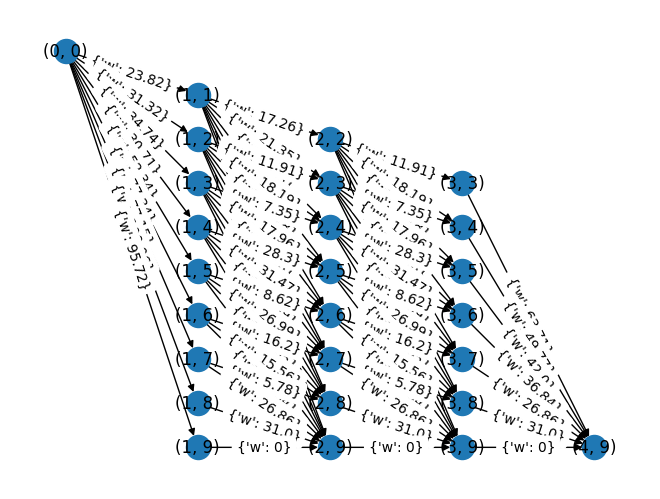

In [199]:
positions = {node: (node[0], N - node[1]) for node in aug_graph.nodes()}

nx.draw(aug_graph, pos=positions, with_labels=True)
nx.draw_networkx_edge_labels(aug_graph, positions)

In [200]:
path = nx.shortest_path(aug_graph, (0, 0), (k, N-1), weight='w')

for edge in path:
    print(inter[edge[1]])

KGX
YRK
NCL
EDB
EDB


In [196]:
print(nx.shortest_path_length(aug_graph, (0, 0), (k, N-1), weight='w'))

76.34


In [197]:
import folium


# Create a base map centered on the UK
m = folium.Map(location=[54.5, -3], zoom_start=6)
cord_old = None
for _, station in path:
    coord = df[df["crsCode"] == inter[station]]["lat"].values[0], df[df["crsCode"] == inter[station]]["long"].values[0]
    # Add a marker for the station
    folium.Marker(location=coord).add_to(m)
    if cord_old is not None:
        # Draw a line between the previous and current station
        folium.PolyLine(locations=(cord_old, coord), color='blue').add_to(m)
    cord_old = coord
m.save("uk_city_edges.html")